## Fig. 2a & 2b

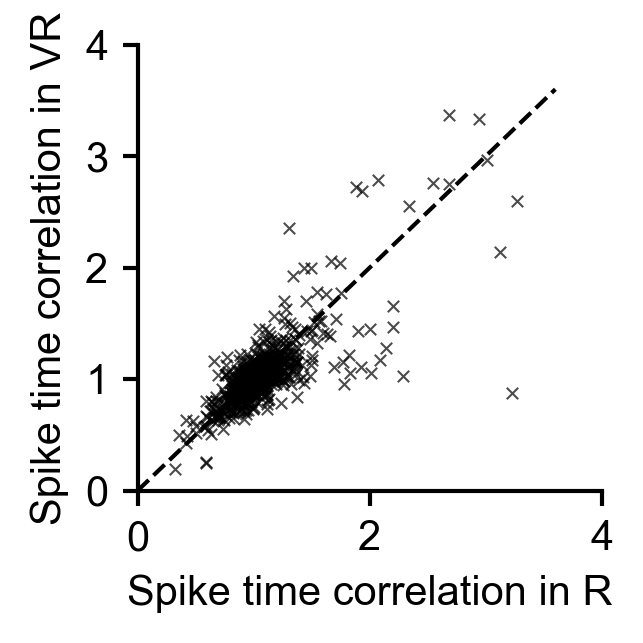

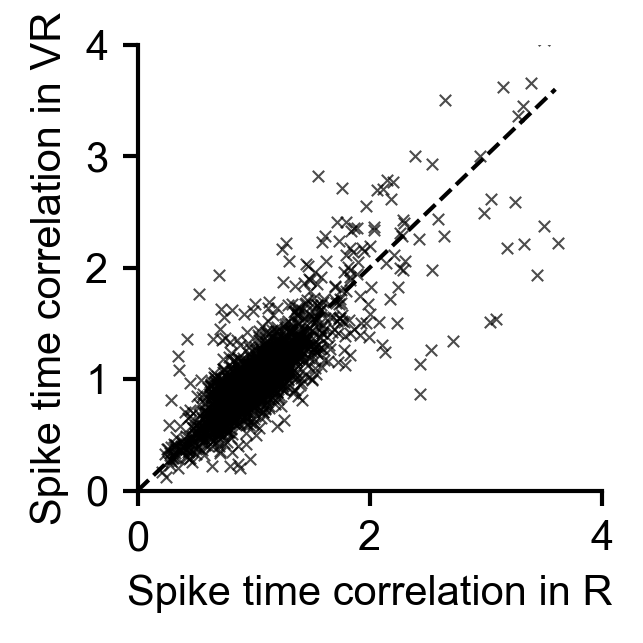

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.stats import pearsonr

def _to_py(x):
    if isinstance(x, np.ndarray):
        if x.size == 0:
            return None
        if x.size == 1:
            return _to_py(x.item())
    return x

def get_field(obj, name, default=None):
    if obj is None:
        return default
    if isinstance(obj, np.void) and obj.dtype.names and name in obj.dtype.names:
        return _to_py(obj[name])
    if isinstance(obj, dict) and name in obj:
        return _to_py(obj[name])
    if hasattr(obj, name):
        return _to_py(getattr(obj, name))
    return default

def as_1d_array(x):
    if x is None:
        return np.array([], dtype=float)

    arr = np.asarray(x).squeeze()

    if arr.size == 0:
        return np.array([], dtype=float)

    return arr.astype(float).ravel()

mergeDays = [
    [list(range(1, 8)), list(range(8, 16))],
    [list(range(1, 6)), list(range(6, 11))],
    [list(range(1, 3)), list(range(3, 6))],
    [list(range(1, 6)), list(range(6, 11))],
    [list(range(1, 6)), list(range(6, 12))],
    [[1], list(range(2, 4))],
    [list(range(1, 10)), list(range(10, 19))],
    [list(range(1, 9)), list(range(9, 17))]
]

mat = loadmat("../Results4Plots/SpikeTime_correlation.mat", squeeze_me=True, struct_as_record=False)
data_list = list(np.atleast_1d(mat["data"]))

earlyR = []
earlyVR = []
lateR = []
lateVR = []

for ia, animal in enumerate(data_list):
    if ia >= len(mergeDays):
        continue

    trials = get_field(animal, "trials")

    if trials is None:
        continue

    trials = np.atleast_1d(trials)

    for group, days in enumerate(mergeDays[ia]):
        for day in days:
            day_idx = day - 1

            if day_idx < 0 or day_idx >= len(trials):
                continue

            tr = trials[day_idx]

            x = as_1d_array(get_field(tr, "pairR_ratio"))
            y = as_1d_array(get_field(tr, "pairVR_ratio"))

            if x.size == 0 or y.size == 0:
                continue

            n = min(x.size, y.size)
            x = x[:n]
            y = y[:n]

            keep = np.isfinite(x) & np.isfinite(y)

            if not np.any(keep):
                continue

            if group == 0:
                earlyR.append(x[keep])
                earlyVR.append(y[keep])
            else:
                lateR.append(x[keep])
                lateVR.append(y[keep])

earlyR = np.concatenate(earlyR) if earlyR else np.array([], dtype=float)
earlyVR = np.concatenate(earlyVR) if earlyVR else np.array([], dtype=float)
lateR = np.concatenate(lateR) if lateR else np.array([], dtype=float)
lateVR = np.concatenate(lateVR) if lateVR else np.array([], dtype=float)

def plot_stage_scatter(x, y, lims=(0, 4), s=7.5):
    fig, ax = plt.subplots(figsize=(2, 2), dpi=300)

    ax.scatter(x, y, s=s, marker="x", color="black", linewidths=0.5, alpha=0.7)

    x2 = lims[0] + 0.9 * (lims[1] - lims[0])
    ax.plot([lims[0], x2], [lims[0], x2], "k--", linewidth=1)


    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)

    ax.tick_params(axis="both", direction="out", length=3.5, width=1, labelsize=10)

    for item in ax.get_xticklabels() + ax.get_yticklabels():
        item.set_fontname("Arial")

    ax.set_xlabel("Spike time correlation in R", fontsize=10, fontname="Arial")
    ax.set_ylabel("Spike time correlation in VR", fontsize=10, fontname="Arial")
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    fig.tight_layout(pad=0.2)
    plt.show()

plot_stage_scatter(
    earlyR,
    earlyVR,
)

plot_stage_scatter(
    lateR,
    lateVR,
)

## Fig. 2d

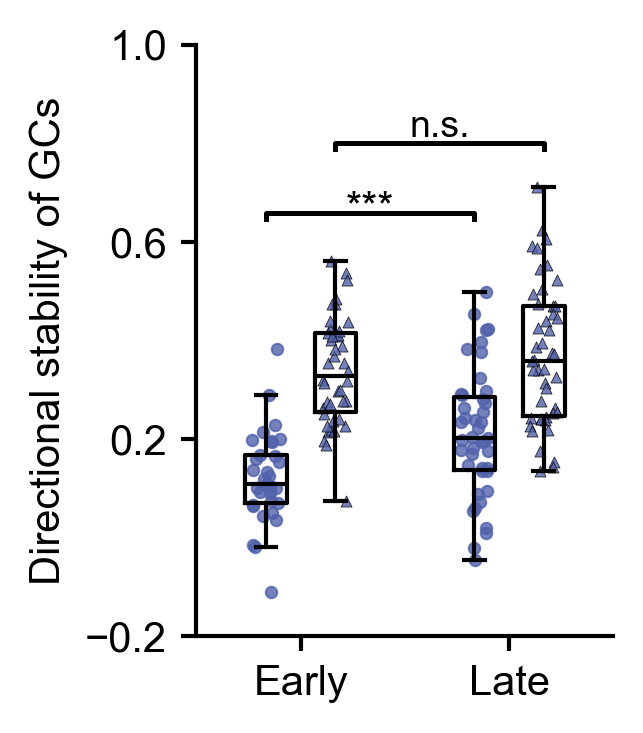

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../Results4Plots/directional stability_GCs.csv").copy()
df = df.copy()
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

df = df[
    (df["Stage"].isin(["early", "late"]))
    & (df["Env"].isin(["VR", "R"]))
    & (df["Value"].notna())
].copy()

stage_levels = ["early", "late"]
env_levels = ["VR", "R"]

colorGC = np.array([81, 98, 172]) / 255.0

xpos = {
    ("early", "VR"): 1,
    ("early", "R"): 2,
    ("late", "VR"): 4,
    ("late", "R"): 5
}

rng = np.random.default_rng(0)
jitter_width = 0.4

fig, ax = plt.subplots(figsize=(2, 2.3), dpi=300)

for st in stage_levels:
    for env in env_levels:
        sub = df[(df["Stage"] == st) & (df["Env"] == env)]
        y = sub["Value"].to_numpy(dtype=float)
        y = y[np.isfinite(y)]

        if y.size == 0:
            continue

        x0 = xpos[(st, env)]
        jitter = (rng.random(y.size) - 0.5) * jitter_width

        if env == "VR":
            ax.scatter(x0 + jitter, y, s=7.5, marker="o", facecolors=colorGC, edgecolors=colorGC, linewidths=0.5, alpha=0.8, zorder=1)
        else:
            ax.scatter(x0 + jitter, y, s=7, marker="^", facecolors=colorGC, edgecolors="k", linewidths=0.2, alpha=0.8, zorder=1)

        bp = ax.boxplot(
            y,
            positions=[x0],
            widths=0.6,
            showfliers=False,
            patch_artist=False,
            boxprops=dict(color="k", linewidth=1),
            medianprops=dict(color="k", linewidth=1),
            whiskerprops=dict(color="k", linewidth=1),
            capprops=dict(color="k", linewidth=1)
        )

        for k in ["boxes", "medians", "whiskers", "caps"]:
            for artist in bp[k]:
                artist.set_zorder(10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for item in ax.get_yticklabels():
    item.set_fontname("Arial")

ax.set_ylabel("Directional stability of GCs", fontsize=10, fontname="Arial")
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)

ymin, ymax = ax.get_ylim()
yr = ymax - ymin
h = 0.015 * yr
gap = 0.02 * yr
text_offset = 0.009 * yr

vr_values = df.loc[df["Env"] == "VR", "Value"].to_numpy(dtype=float)
r_values = df.loc[df["Env"] == "R", "Value"].to_numpy(dtype=float)

vr_values = vr_values[np.isfinite(vr_values)]
r_values = r_values[np.isfinite(r_values)]

y_vr = np.nanmax(vr_values) + gap + 0.13
y_r = np.nanmax(r_values) + gap + 0.12 * yr - 0.05

ax.plot([1, 1, 4, 4], [y_vr, y_vr + h, y_vr + h, y_vr], lw=1.2, c="k")
ax.text(2.5, y_vr + h + text_offset - 0.04, "***", ha="center", va="bottom", fontname="Arial", fontsize=10)

ax.plot([2, 2, 5, 5], [y_r, y_r + h, y_r + h, y_r], lw=1.2, c="k")
ax.text(3.5, y_r + h + text_offset - 0.01, "n.s.", ha="center", va="bottom", fontname="Arial", fontsize=9)

ax.set_ylim(-0.2, 1)
ax.set_yticks([-0.2, 0.2, 0.6, 1])
ax.set_xlim(0, 6)

plt.tight_layout(pad=0.2)
plt.show()

## Fig. 2e

Early: peak at x=7, y=0.1446, sem=0.0362
Late: peak at x=3, y=0.2924, sem=0.0225
Early: peak at x=4, y=0.1781, sem=0.0433
Late: peak at x=3, y=0.2789, sem=0.0258


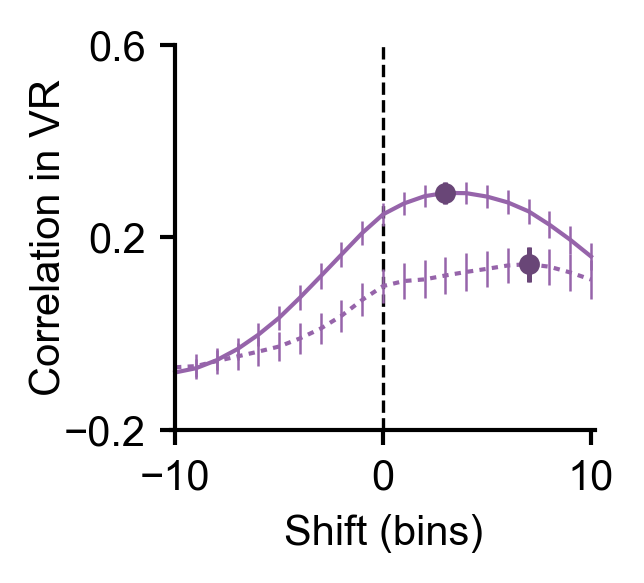

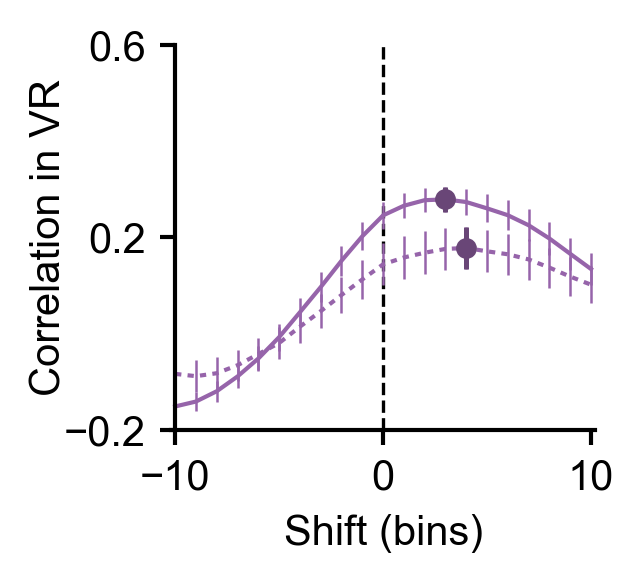

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

dataA = np.atleast_1d(loadmat("../Results4Plots/GC_shift_VR_NS.mat", squeeze_me=True, struct_as_record=False)["a"])
dataB = np.atleast_1d(loadmat("../Results4Plots/GC_shift_VR_WE.mat", squeeze_me=True, struct_as_record=False)["b"])

shifts = np.arange(0, 11)
nShift = len(shifts)
thrgs = 0.12

mergeDays = [
    [list(range(1, 8)), list(range(8, 16))],
    [list(range(1, 6)), list(range(6, 11))],
    [list(range(1, 3)), list(range(3, 6))],
    [list(range(1, 6)), list(range(6, 11))],
    [list(range(1, 6)), list(range(6, 12))],
    [[1], [2, 3]],
    [list(range(1, 10)), list(range(10, 19))],
    [list(range(1, 9)), list(range(9, 17))]
]

def get_field(obj, key, default=None):
    if obj is None:
        return default
    if isinstance(obj, dict):
        return obj.get(key, default)
    return getattr(obj, key, default)

def ensure_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, tuple):
        return list(x)
    if isinstance(x, np.ndarray):
        if x.dtype == object:
            return list(x.flat)
        if x.ndim == 0:
            return [x.item()]
        return list(x)
    return [x]

def to_shift_x_n(x, n_shift):
    if x is None:
        return None

    x = np.asarray(x)

    if x.size == 0:
        return None

    if x.dtype == object and x.size == 1:
        x = x.item()
        if x is None:
            return None
        x = np.asarray(x)
        if x.size == 0:
            return None

    x = np.asarray(x, dtype=float)

    if x.ndim == 1:
        return x[:, None] if x.shape[0] == n_shift else None

    if x.ndim != 2:
        return None

    if x.shape[0] == n_shift:
        return x

    if x.shape[1] == n_shift:
        return x.T

    return None

def get_comp_cells(T1, f1, T2, f2, n_shift):
    A = to_shift_x_n(get_field(T1, f1), n_shift)
    B = to_shift_x_n(get_field(T2, f2), n_shift)

    if A is None or B is None:
        return None

    n_cells = min(A.shape[1], B.shape[1])

    if n_cells == 0:
        return None

    return (A[:, :n_cells] + B[:, :n_cells]) / 2

def get_stage(day, early_days, late_days):
    if day in early_days:
        return "early"
    if day in late_days:
        return "late"
    return None

def get_grid_mask(trial, n_cells, threshold):
    keep = np.zeros(n_cells, dtype=bool)

    for field in ["Ngs", "Sgs", "Wgs", "Egs"]:
        values = get_field(trial, field)

        if values is None:
            continue

        values = np.asarray(values, dtype=float).ravel()
        n = min(n_cells, values.size)
        keep[:n] |= np.isfinite(values[:n]) & (values[:n] > threshold)

    return keep

def build_curve(against, with_direction):
    y_left = against[::-1]
    y0 = np.nanmean([y_left[-1], with_direction[0]])
    return np.concatenate([y_left[:-1], [y0], with_direction[1:]])

def mean_sem(curves):
    curves = np.asarray(curves, dtype=float)
    mean = np.nanmean(curves, axis=0)
    n = np.sum(np.isfinite(curves), axis=0)
    sem = np.nanstd(curves, axis=0, ddof=0) / np.sqrt(np.maximum(n, 1))
    return mean, sem

def darken_color(color, factor=0.7):
    return np.clip(np.asarray(color, dtype=float) * factor, 0, 1)

def plot_mean_sem_style(ax, x, curves, color, line_style, label):
    if len(curves) == 0:
        return

    mean, sem = mean_sem(curves)

    eb = ax.errorbar(x, mean, yerr=sem, fmt=line_style, linewidth=1, markersize=2, elinewidth=0.6, color=color, label=label, zorder=2)

    if "--" in line_style:
        eb[0].set_dashes([1.5, 1.5])

    if not np.any(np.isfinite(mean)):
        return

    peak_idx = np.nanargmax(mean)
    peak_color = darken_color(color)

    ax.errorbar(
        [x[peak_idx]],
        [mean[peak_idx]],
        yerr=[sem[peak_idx]],
        fmt="o",
        markersize=4,
        color=peak_color,
        ecolor=peak_color,
        elinewidth=1.2,
        capsize=0,
        markerfacecolor=peak_color,
        markeredgecolor=peak_color,
        zorder=5
    )

    print(f"{label}: peak at x={x[peak_idx]}, y={mean[peak_idx]:.4f}, sem={sem[peak_idx]:.4f}")

curvesNS = {"early": [], "late": []}
curvesWE = {"early": [], "late": []}

for ia in range(min(len(dataA), len(dataB), len(mergeDays))):
    earlyDays, lateDays = mergeDays[ia]

    trialsA = ensure_list(get_field(dataA[ia], "trials"))
    trialsB = ensure_list(get_field(dataB[ia], "trials"))

    for iday0 in range(min(len(trialsA), len(trialsB))):
        stage = get_stage(iday0 + 1, earlyDays, lateDays)

        if stage is None:
            continue

        TA = trialsA[iday0]
        TB = trialsB[iday0]

        L1 = get_comp_cells(TA, "r_NS1", TB, "r_NS", nShift)
        L2 = get_comp_cells(TA, "r_NS", TB, "r_NS1", nShift)
        L3 = get_comp_cells(TB, "r_WE1", TA, "r_WE", nShift)
        L4 = get_comp_cells(TA, "r_WE1", TB, "r_WE", nShift)

        if any(x is None for x in [L1, L2, L3, L4]):
            continue

        n_cells = min(L1.shape[1], L2.shape[1], L3.shape[1], L4.shape[1])

        if n_cells == 0:
            continue

        L1 = L1[:, :n_cells]
        L2 = L2[:, :n_cells]
        L3 = L3[:, :n_cells]
        L4 = L4[:, :n_cells]

        keep = get_grid_mask(TA, n_cells, thrgs)

        if not np.any(keep):
            continue

        against_NS = np.nanmean(L1[:, keep], axis=1)
        with_NS = np.nanmean(L2[:, keep], axis=1)
        against_WE = np.nanmean(L4[:, keep], axis=1)
        with_WE = np.nanmean(L3[:, keep], axis=1)

        curve_NS = build_curve(against_NS, with_NS)
        curve_WE = build_curve(against_WE, with_WE)

        if np.any(np.isfinite(curve_NS)):
            curvesNS[stage].append(curve_NS)

        if np.any(np.isfinite(curve_WE)):
            curvesWE[stage].append(curve_WE)

for stage in ["early", "late"]:
    curvesNS[stage] = np.asarray(curvesNS[stage], dtype=float)
    curvesWE[stage] = np.asarray(curvesWE[stage], dtype=float)

curve_color = np.array([150, 100, 170]) / 255.0
maxShift = shifts[-1]
x_full = np.arange(-maxShift, maxShift + 1)

def plot_panel(curves, outpath):
    fig, ax = plt.subplots(figsize=(2, 1.8), dpi=300)

    plot_mean_sem_style(ax, x_full, curves["early"], curve_color, "--", "Early")
    plot_mean_sem_style(ax, x_full, curves["late"], curve_color, "-", "Late")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)
    ax.spines["left"].set_position(("data", -10))

    ax.tick_params(direction="out", length=3.5, width=1, labelsize=10)

    for item in ax.get_xticklabels() + ax.get_yticklabels():
        item.set_fontname("Arial")

    ax.set_xlim(-(maxShift + 0.2), maxShift + 0.2)
    ax.set_ylim(-0.2, 0.6)
    ax.set_yticks([-0.2, 0.2, 0.6])
    ax.set_xlabel("Shift (bins)", fontsize=10, fontname="Arial")
    ax.set_ylabel("Correlation in VR", fontsize=10, fontname="Arial", labelpad=-1)
    ax.axvline(0, color="k", linestyle="--", linewidth=0.8, zorder=1)

    fig.tight_layout(pad=0.2)

plot_panel(curvesNS, "../Figures_v2/Fig2_B11.pdf")
plot_panel(curvesWE, "../Figures_v2/Fig2_B21.pdf")

plt.show()

## Fig. 2f

Early: peak at x=1, y=0.3875, sem=0.0217
Late: peak at x=1, y=0.4140, sem=0.0238
Early: peak at x=2, y=0.3956, sem=0.0170
Late: peak at x=2, y=0.4116, sem=0.0263


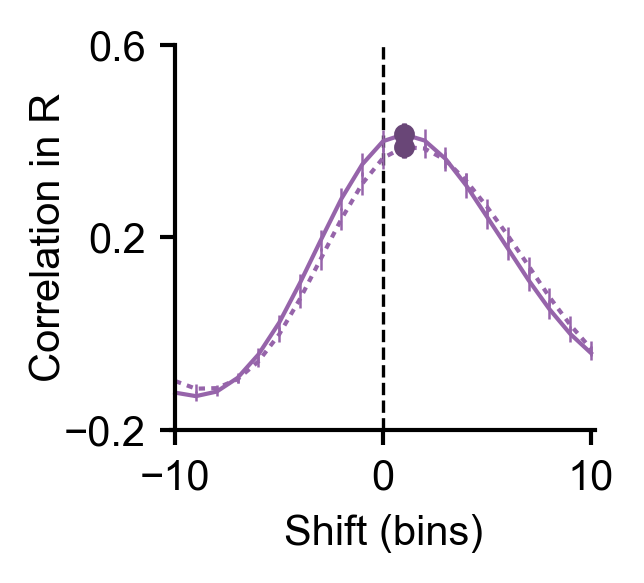

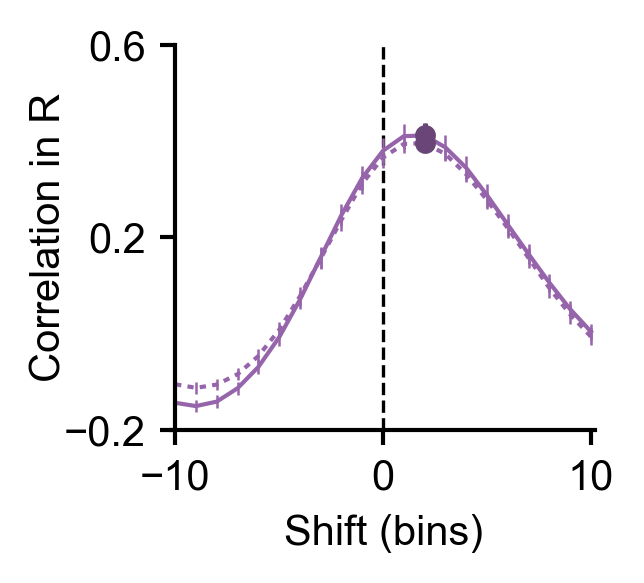

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

dataA = np.atleast_1d(loadmat("../Results4Plots/GC_shift_R_NS, squeeze_me=True, struct_as_record=False)["a"])
dataB = np.atleast_1d(loadmat("../Results4Plots/GC_shift_R_WE", squeeze_me=True, struct_as_record=False)["b"])

shifts = np.arange(0, 11)
nShift = len(shifts)
thrgs = 0.12

mergeDays = [
    [list(range(1, 8)), list(range(8, 16))],
    [list(range(1, 6)), list(range(6, 11))],
    [list(range(1, 3)), list(range(3, 6))],
    [list(range(1, 6)), list(range(6, 11))],
    [list(range(1, 6)), list(range(6, 12))],
    [[1], [2, 3]],
    [list(range(1, 10)), list(range(10, 19))],
    [list(range(1, 9)), list(range(9, 17))]
]

def get_field(obj, key, default=None):
    if obj is None:
        return default
    if isinstance(obj, dict):
        return obj.get(key, default)
    return getattr(obj, key, default)

def ensure_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, tuple):
        return list(x)
    if isinstance(x, np.ndarray):
        if x.dtype == object:
            return list(x.flat)
        if x.ndim == 0:
            return [x.item()]
        return list(x)
    return [x]

def to_shift_x_n(x, n_shift):
    if x is None:
        return None

    x = np.asarray(x)

    if x.size == 0:
        return None

    if x.dtype == object and x.size == 1:
        x = x.item()

        if x is None:
            return None

        x = np.asarray(x)

        if x.size == 0:
            return None

    x = np.asarray(x, dtype=float)

    if x.ndim == 1:
        return x[:, None] if x.shape[0] == n_shift else None

    if x.ndim != 2:
        return None

    if x.shape[0] == n_shift:
        return x

    if x.shape[1] == n_shift:
        return x.T

    return None

def get_comp_cells(T1, f1, T2, f2, n_shift):
    A = to_shift_x_n(get_field(T1, f1), n_shift)
    B = to_shift_x_n(get_field(T2, f2), n_shift)

    if A is None or B is None:
        return None

    n_cells = min(A.shape[1], B.shape[1])

    if n_cells == 0:
        return None

    return (A[:, :n_cells] + B[:, :n_cells]) / 2

def get_stage(day, early_days, late_days):
    if day in early_days:
        return "early"
    if day in late_days:
        return "late"
    return None

def get_grid_mask(trial, n_cells, threshold):
    keep = np.zeros(n_cells, dtype=bool)

    for field in ["Ngs", "Sgs", "Wgs", "Egs"]:
        values = get_field(trial, field)

        if values is None:
            continue

        values = np.asarray(values, dtype=float).ravel()
        n = min(n_cells, values.size)
        keep[:n] |= np.isfinite(values[:n]) & (values[:n] > threshold)

    return keep

def build_curve(against, with_direction):
    y_left = against[::-1]
    y0 = np.nanmean([y_left[-1], with_direction[0]])
    return np.concatenate([y_left[:-1], [y0], with_direction[1:]])

def mean_sem(curves):
    curves = np.asarray(curves, dtype=float)
    mean = np.nanmean(curves, axis=0)
    n = np.sum(np.isfinite(curves), axis=0)
    sem = np.nanstd(curves, axis=0, ddof=0) / np.sqrt(np.maximum(n, 1))
    return mean, sem

def darken_color(color, factor=0.7):
    return np.clip(np.asarray(color, dtype=float) * factor, 0, 1)

def plot_mean_sem_style(ax, x, curves, color, line_style, label):
    if len(curves) == 0:
        return

    mean, sem = mean_sem(curves)

    eb = ax.errorbar(x, mean, yerr=sem, fmt=line_style, linewidth=1, markersize=2, elinewidth=0.6, color=color, label=label, zorder=2)

    if "--" in line_style:
        eb[0].set_dashes([1.5, 1.5])

    if not np.any(np.isfinite(mean)):
        return

    peak_idx = np.nanargmax(mean)
    peak_color = darken_color(color)

    ax.errorbar(
        [x[peak_idx]],
        [mean[peak_idx]],
        yerr=[sem[peak_idx]],
        fmt="o",
        markersize=4,
        color=peak_color,
        ecolor=peak_color,
        elinewidth=1.2,
        capsize=0,
        markerfacecolor=peak_color,
        markeredgecolor=peak_color,
        zorder=5
    )

    print(f"{label}: peak at x={x[peak_idx]}, y={mean[peak_idx]:.4f}, sem={sem[peak_idx]:.4f}")

curvesNS = {"early": [], "late": []}
curvesWE = {"early": [], "late": []}

for ia in range(min(len(dataA), len(dataB), len(mergeDays))):
    earlyDays, lateDays = mergeDays[ia]

    trialsA = ensure_list(get_field(dataA[ia], "trials"))
    trialsB = ensure_list(get_field(dataB[ia], "trials"))

    for iday0 in range(min(len(trialsA), len(trialsB))):
        stage = get_stage(iday0 + 1, earlyDays, lateDays)

        if stage is None:
            continue

        TA = trialsA[iday0]
        TB = trialsB[iday0]

        L1 = get_comp_cells(TA, "r_NS1", TB, "r_NS", nShift)
        L2 = get_comp_cells(TA, "r_NS", TB, "r_NS1", nShift)
        L3 = get_comp_cells(TB, "r_WE1", TA, "r_WE", nShift)
        L4 = get_comp_cells(TA, "r_WE1", TB, "r_WE", nShift)

        if any(x is None for x in [L1, L2, L3, L4]):
            continue

        n_cells = min(L1.shape[1], L2.shape[1], L3.shape[1], L4.shape[1])

        if n_cells == 0:
            continue

        L1 = L1[:, :n_cells]
        L2 = L2[:, :n_cells]
        L3 = L3[:, :n_cells]
        L4 = L4[:, :n_cells]

        keep = get_grid_mask(TA, n_cells, thrgs)

        if not np.any(keep):
            continue

        against_NS = np.nanmean(L1[:, keep], axis=1)
        with_NS = np.nanmean(L2[:, keep], axis=1)
        against_WE = np.nanmean(L4[:, keep], axis=1)
        with_WE = np.nanmean(L3[:, keep], axis=1)

        curve_NS = build_curve(against_NS, with_NS)
        curve_WE = build_curve(against_WE, with_WE)

        if np.any(np.isfinite(curve_NS)):
            curvesNS[stage].append(curve_NS)

        if np.any(np.isfinite(curve_WE)):
            curvesWE[stage].append(curve_WE)

for stage in ["early", "late"]:
    curvesNS[stage] = np.asarray(curvesNS[stage], dtype=float)
    curvesWE[stage] = np.asarray(curvesWE[stage], dtype=float)

curve_color = np.array([150, 100, 170]) / 255.0
maxShift = shifts[-1]
x_full = np.arange(-maxShift, maxShift + 1)

def plot_panel(curves, outpath):
    fig, ax = plt.subplots(figsize=(2, 1.8), dpi=300)

    plot_mean_sem_style(ax, x_full, curves["early"], curve_color, "--", "Early")
    plot_mean_sem_style(ax, x_full, curves["late"], curve_color, "-", "Late")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)
    ax.spines["left"].set_position(("data", -10))

    ax.tick_params(direction="out", length=3.5, width=1, labelsize=10)

    for item in ax.get_xticklabels() + ax.get_yticklabels():
        item.set_fontname("Arial")

    ax.set_xlim(-(maxShift + 0.2), maxShift + 0.2)
    ax.set_ylim(-0.2, 0.6)
    ax.set_yticks([-0.2, 0.2, 0.6])
    ax.set_xlabel("Shift (bins)", fontsize=10, fontname="Arial")
    ax.set_ylabel("Correlation in R", fontsize=10, fontname="Arial", labelpad=-1)
    ax.axvline(0, color="k", linestyle="--", linewidth=0.8, zorder=1)

    fig.tight_layout(pad=0.2)

plot_panel(curvesNS, "../Figures_v2/Fig2_C3.pdf")
plot_panel(curvesWE, "../Figures_v2/Fig2_C4.pdf")

plt.show()